In [14]:
# Load data từ HuggingFace
from datasets import load_dataset

dataset = load_dataset("ura-hcmut/vlsp2016")
df_train = dataset['train'].to_pandas()
df_test  = dataset['test'].to_pandas()

print(df_train.shape)        # (5100, 2)
print(df_train.columns)      # ['Class', 'Data']
print(df_train['Class'].value_counts())

(5100, 2)
Index(['Class', 'Data'], dtype='object')
Class
negative    1700
positive    1700
neutral     1700
Name: count, dtype: int64


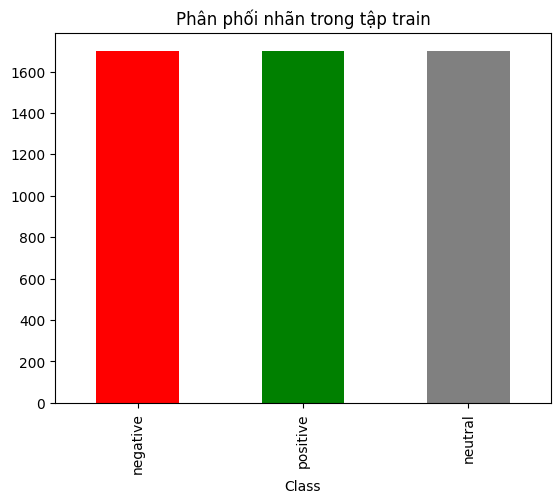

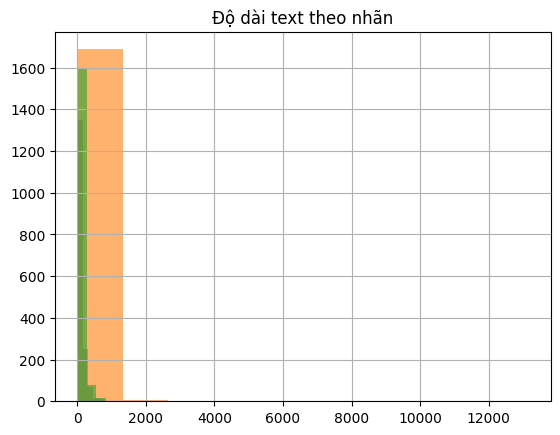

Class       0
Data        0
text_len    0
dtype: int64


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Phân phối nhãn
df_train['Class'].value_counts().plot(kind='bar', color=['red','green','gray'])
plt.title('Phân phối nhãn trong tập train')
plt.show()

# 2. Độ dài văn bản
df_train['text_len'] = df_train['Data'].apply(len)
df_train.groupby('Class')['text_len'].hist(alpha=0.6)
plt.title('Độ dài text theo nhãn')
plt.show()

# 3. Kiểm tra missing
print(df_train.isnull().sum())

🔍 KIỂM TRA CHẤT LƯỢNG DATASET

📌 1. Kiểm tra dữ liệu bị NULL:
Class       0
Data        0
text_len    0
dtype: int64
✅ Tuyệt vời! Không có dữ liệu nào bị NULL.

📌 2. Kiểm tra mất cân bằng lớp (Class Imbalance):
Class
negative    1700
positive    1700
neutral     1700
Name: count, dtype: int64

📊 Tỷ lệ phần trăm:
Class
negative    33.33
positive    33.33
neutral     33.33
Name: count, dtype: float64

🔎 Tỷ lệ giữa lớp lớn nhất và nhỏ nhất: 1.00x
✅ Dataset CÂN BẰNG tốt! Không cần xử lý gì thêm.


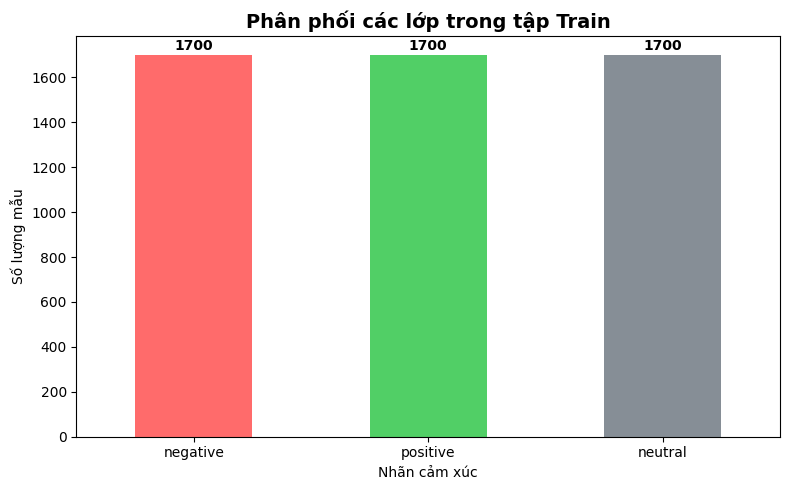


📌 3. Kiểm tra độ dài văn bản:

📈 Thống kê độ dài (số ký tự):
count     5100.000000
mean       129.749020
std        309.700932
min          2.000000
25%         45.000000
50%         81.000000
75%        146.000000
max      13164.000000
Name: text_len, dtype: float64

📊 Độ dài trung bình theo từng lớp:
            mean  median  min    max
Class                               
negative  112.16    77.0    3   1532
neutral   173.53   102.0    7  13164
positive  103.55    69.0    2   2753


/tmp/ipykernel_6086/1571434650.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Class', y='text_len', palette=colors)


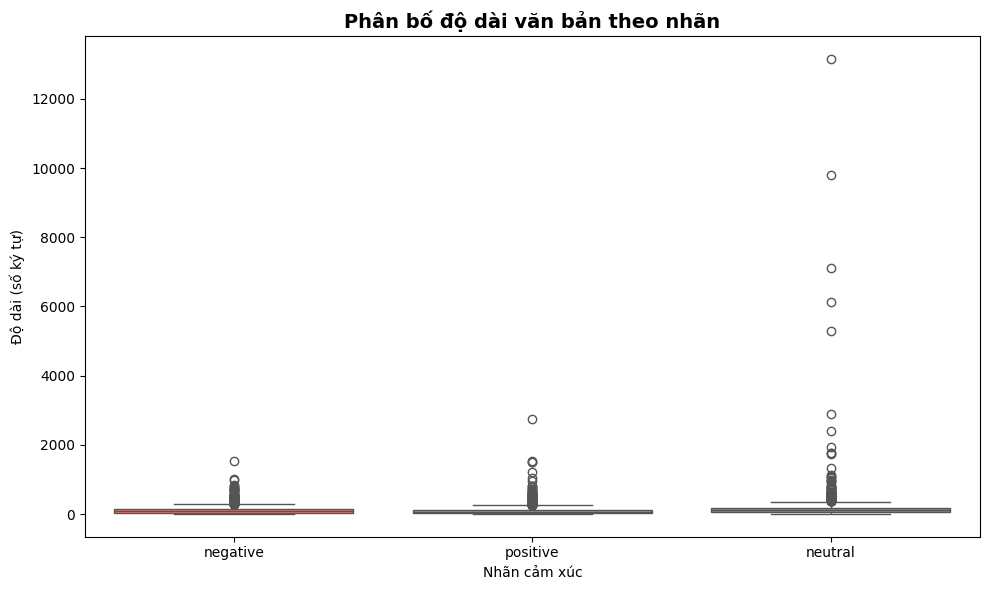

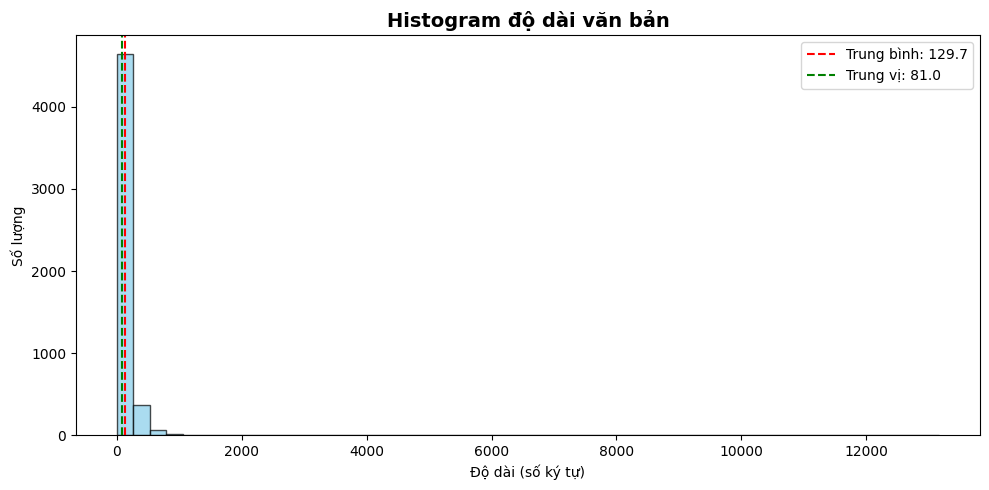

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("🔍 KIỂM TRA CHẤT LƯỢNG DATASET")
print("=" * 50)

# ==========================================
# 1. KIỂM TRA DỮ LIỆU NULL (Missing Values)
# ==========================================
print("\n📌 1. Kiểm tra dữ liệu bị NULL:")
null_counts = df_train.isnull().sum()
print(null_counts)

if null_counts.sum() == 0:
    print("✅ Tuyệt vời! Không có dữ liệu nào bị NULL.")
else:
    print(f"⚠️ Cảnh báo: Có {null_counts.sum()} giá trị NULL trong dataset!")
    # Cách xử lý nếu có null:
    # df_train = df_train.dropna()  # Xóa dòng null
    # hoặc df_train['Data'] = df_train['Data'].fillna('')  # Điền giá trị rỗng

# ==========================================
# 2. KIỂM TRA MẤT CÂN BẰNG (Imbalanced Data)
# ==========================================
print("\n📌 2. Kiểm tra mất cân bằng lớp (Class Imbalance):")
class_dist = df_train['Class'].value_counts()
print(class_dist)

# Tính tỷ lệ phần trăm
class_pct = (class_dist / len(df_train) * 100).round(2)
print("\n📊 Tỷ lệ phần trăm:")
print(class_pct)

# Đánh giá
max_ratio = class_dist.max() / class_dist.min()
print(f"\n🔎 Tỷ lệ giữa lớp lớn nhất và nhỏ nhất: {max_ratio:.2f}x")
if max_ratio > 2:
    print("⚠️ Dataset MẤT CÂN BẰNG nghiêm trọng! Cần xử lý (SMOTE/class_weight).")
elif max_ratio > 1.5:
    print("⚡ Dataset hơi mất cân bằng nhẹ. Có thể dùng class_weight='balanced'.")
else:
    print("✅ Dataset CÂN BẰNG tốt! Không cần xử lý gì thêm.")

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
colors = ['#ff6b6b', '#51cf66', '#868e96']
class_dist.plot(kind='bar', color=colors)
plt.title('Phân phối các lớp trong tập Train', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn cảm xúc')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=0)
for i, v in enumerate(class_dist.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 3. KIỂM TRA ĐỘ DÀI VĂN BẢN (Text Length)
# ==========================================
print("\n📌 3. Kiểm tra độ dài văn bản:")
df_train['text_len'] = df_train['Data'].apply(len)

# Thống kê tổng quan
print("\n📈 Thống kê độ dài (số ký tự):")
print(df_train['text_len'].describe())

# Thống kê theo từng lớp
print("\n📊 Độ dài trung bình theo từng lớp:")
len_by_class = df_train.groupby('Class')['text_len'].agg(['mean', 'median', 'min', 'max'])
print(len_by_class.round(2))

# Vẽ biểu đồ boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_train, x='Class', y='text_len', palette=colors)
plt.title('Phân bố độ dài văn bản theo nhãn', fontsize=14, fontweight='bold')
plt.ylabel('Độ dài (số ký tự)')
plt.xlabel('Nhãn cảm xúc')
plt.tight_layout()
plt.show()

# Vẽ histogram độ dài
plt.figure(figsize=(10, 5))
plt.hist(df_train['text_len'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(df_train['text_len'].mean(), color='red', linestyle='--', 
            label=f"Trung bình: {df_train['text_len'].mean():.1f}")
plt.axvline(df_train['text_len'].median(), color='green', linestyle='--', 
            label=f"Trung vị: {df_train['text_len'].median():.1f}")
plt.title('Histogram độ dài văn bản', fontsize=14, fontweight='bold')
plt.xlabel('Độ dài (số ký tự)')
plt.ylabel('Số lượng')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
!pip install underthesea tqdm scikit-learn

In [18]:
import re
import pandas as pd
from underthesea import word_tokenize # ĐÃ SỬA: Đổi từ word_segment sang word_tokenize
from tqdm.auto import tqdm

# Kích hoạt thanh tiến trình
tqdm.pandas(desc="Đang xử lý văn bản")

def clean_and_segment_vietnamese(text):
    """
    Hàm làm sạch và tách từ tiếng Việt (Đã cập nhật API mới)
    """
    if not isinstance(text, str):
        return ""
        
    # 1. Chuyển về chữ thường
    text = text.lower()
    
    # 2. Loại bỏ URL, email, mention
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    
    # 3. Loại bỏ ký tự đặc biệt, chỉ giữ chữ cái tiếng Việt và số
    text = re.sub(r'[^a-zàáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ0-9\s]', ' ', text)
    
    # 4. Tách từ ghép tiếng Việt (SỬ DỤNG API MỚI)
    # word_tokenize trả về 1 list các từ/cụm từ, ví dụ: ['máy', 'tính', 'rất', 'tốt']
    tokens = word_tokenize(text)
    
    # Nối các từ bằng dấu gạch dưới để TF-IDF hiểu là 1 cụm từ (ví dụ: "máy_tính_rất_tốt")
    text = "_".join(tokens)
    
    # 5. Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# ==========================================
# ÁP DỤNG VÀO DỮ LIỆU
# ==========================================
print(" Bắt đầu tiền xử lý tập Train...")
df_train['clean_text'] = df_train['Data'].progress_apply(clean_and_segment_vietnamese)

print("\n🚀 Bắt đầu tiền xử lý tập Test...")
df_test['clean_text'] = df_test['Data'].progress_apply(clean_and_segment_vietnamese)

# ==========================================
# KIỂM TRA KẾT QUẢ
# ==========================================
print("\n" + "="*50)
print("✨ KẾT QUẢ TIỀN XỬ LÝ (Before vs After)")
print("="*50)

# Lấy ngẫu nhiên 3 mẫu để kiểm tra
sample_indices = df_train.sample(3).index
for idx in sample_indices:
    print(f"\n🔹 Mẫu {idx}:")
    print(f"   - Gốc:     {df_train.loc[idx, 'Data']}")
    print(f"   - Đã xử lý: {df_train.loc[idx, 'clean_text']}")

 Bắt đầu tiền xử lý tập Train...


Đang xử lý văn bản:   0%|          | 0/5100 [00:00<?, ?it/s]


🚀 Bắt đầu tiền xử lý tập Test...


Đang xử lý văn bản:   0%|          | 0/1050 [00:00<?, ?it/s]


✨ KẾT QUẢ TIỀN XỬ LÝ (Before vs After)

🔹 Mẫu 903:
   - Gốc:     màu sắc tái tái
   - Đã xử lý: màu sắc_tái tái

🔹 Mẫu 2991:
   - Gốc:     Dung la rat dep nhung day chi la phong doan
   - Đã xử lý: dung_la rat_dep_nhung_day_chi la_phong doan

🔹 Mẫu 3935:
   - Gốc:     chắc so được với 950 không nguồn phụ
   - Đã xử lý: chắc_so_được_với_950_không_nguồn_phụ


In [23]:
import pandas as pd
import numpy as np
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, f1_score

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU & MÃ HÓA NHÃN
# ==========================================
# Chuẩn hóa lại text: thay dấu gạch dưới (_) thành khoảng trắng để TF-IDF tự bắt n-gram
df_train['final_text'] = df_train['clean_text'].str.replace('_', ' ', regex=False)
df_test['final_text'] = df_test['clean_text'].str.replace('_', ' ', regex=False)

# Mã hóa nhãn (Class) thành số
le = LabelEncoder()
y_train = le.fit_transform(df_train['Class'])
y_test = le.transform(df_test['Class'])
print("📌 Nhãn đã mã hóa:", le.classes_)

# ==========================================
# 2. TF-IDF VECTORIZER
# ==========================================
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),      # TF-IDF tự động bắt cụm từ (bigram)
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

print("\n⚙️ Đang chuyển đổi văn bản thành ma trận số...")
X_train_tfidf = tfidf.fit_transform(df_train['final_text'])
X_test_tfidf = tfidf.transform(df_test['final_text'])
print(f"✅ Kích thước ma trận: {X_train_tfidf.shape}")

# ==========================================
# 3. TRAIN & ĐÁNH GIÁ CHUYÊN SÂU
# ==========================================
models = {
    "Linear SVM": LinearSVC(max_iter=2000, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Multinomial NB": MultinomialNB()
}

best_f1 = 0
best_model_name = ""
best_model_obj = None

print("\n" + "="*60)
print(" KẾT QUẢ ĐÁNH GIÁ CHI TIẾT")
print("="*60)

for name, model in models.items():
    # Train
    model.fit(X_train_tfidf, y_train)
    
    # Predict
    y_pred = model.predict(X_test_tfidf)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted') # Dùng weighted F1 cho bài toán đa lớp
    
    print(f"\n {name}")
    print(f"   🎯 Accuracy: {acc:.4f} | Weighted F1: {f1:.4f}")
    
    # In Classification Report
    print("\n📊 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    # Cập nhật best model dựa trên F1-score (vì F1 phản ánh tốt hơn Accuracy với đa lớp)
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_model_obj = model

# ==========================================
# 4. LƯU MÔ HÌNH TỐT NHẤT (DEPLOYMENT READY)
# ==========================================
print("\n" + "="*60)
print(f"🌟 MÔ HÌNH TỐT NHẤT: {best_model_name} (F1: {best_f1:.4f})")
print("="*60)

# Lưu lại 3 thứ quan trọng nhất để dùng cho bước Predict sau này
joblib.dump(best_model_obj, 'best_sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("💾 Đã lưu thành công: best_sentiment_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl")

📌 Nhãn đã mã hóa: ['negative' 'neutral' 'positive']

⚙️ Đang chuyển đổi văn bản thành ma trận số...
✅ Kích thước ma trận: (5100, 11595)

 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT

 Linear SVM
   🎯 Accuracy: 0.6981 | Weighted F1: 0.6988

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.71      0.70       350
     neutral       0.65      0.67      0.66       350
    positive       0.77      0.72      0.74       350

    accuracy                           0.70      1050
   macro avg       0.70      0.70      0.70      1050
weighted avg       0.70      0.70      0.70      1050


 Logistic Regression
   🎯 Accuracy: 0.7048 | Weighted F1: 0.7057

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.69      0.69       350
     neutral       0.66      0.70      0.68       350
    positive       0.78      0.72      0.75       350

    accuracy                           0.70      1050
   macro

In [25]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Tạo thư mục project (nếu chưa có)
import os
os.makedirs('/content/drive/MyDrive/sentiment_vlsp2016', exist_ok=True)

# Lưu 3 file vào Drive
joblib.dump(best_model_obj, '/content/drive/MyDrive/sentiment_vlsp2016/best_sentiment_model.pkl')
joblib.dump(tfidf,          '/content/drive/MyDrive/sentiment_vlsp2016/tfidf_vectorizer.pkl')
joblib.dump(le,             '/content/drive/MyDrive/sentiment_vlsp2016/label_encoder.pkl')

print("✅ Đã lưu lên Google Drive tại:")
print("   📁 MyDrive/sentiment_vlsp2016/")
print("      ├── best_sentiment_model.pkl")
print("      ├── tfidf_vectorizer.pkl")
print("      └── label_encoder.pkl")

Mounted at /content/drive
✅ Đã lưu lên Google Drive tại:
   📁 MyDrive/sentiment_vlsp2016/
      ├── best_sentiment_model.pkl
      ├── tfidf_vectorizer.pkl
      └── label_encoder.pkl
